# Chapter 11.2: Online Evaluation & Metrics

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Define and compute conversion funnel metrics** (CTR, CVR, GMV) for recommendation systems
2. **Measure user engagement** through session duration, scroll depth, and video watch time
3. **Track retention metrics** including D1/D7/D30 retention and returning user rate
4. **Understand long-term metrics** such as LTV and user satisfaction indices
5. **Identify appropriate North Star metrics** for different product types
6. **Analyse metric trade-offs** and understand how optimising one metric can hurt another
7. **Build a metric dashboard** with funnel analysis and visualisations

## Prerequisites

- Basic understanding of A/B testing concepts
- Familiarity with pandas and matplotlib
- Chapter 11.1 (Offline Evaluation)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part11/chapter_11.2_online_eval.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part11/chapter_11.2_online_eval.ipynb)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from collections import defaultdict

np.random.seed(42)
plt.style.use('seaborn-v0_8')
print("All imports successful.")

All imports successful.


## 1. Generating Synthetic Online Event Data

We simulate an e-commerce recommendation platform with user sessions containing impressions, clicks, add-to-carts, and purchases.

In [2]:
rng = np.random.RandomState(42)
NUM_USERS = 2000
NUM_DAYS = 30

# Generate user profiles
user_signup_day = rng.randint(0, 15, size=NUM_USERS)  # signup within first 15 days
user_base_activity = rng.exponential(0.3, size=NUM_USERS)  # activity level

# Group assignment: control (A) vs treatment (B)
group = np.where(rng.random(NUM_USERS) < 0.5, 'control', 'treatment')

# Generate daily events
events = []
base_date = datetime(2024, 1, 1)

for day in range(NUM_DAYS):
    current_date = base_date + timedelta(days=day)
    for uid in range(NUM_USERS):
        if day < user_signup_day[uid]:
            continue  # user hasn't signed up yet
        
        # Probability of visiting today
        days_since_signup = day - user_signup_day[uid]
        visit_prob = min(0.8, user_base_activity[uid]) * (0.95 ** (days_since_signup / 7))
        
        if rng.random() > visit_prob:
            continue
        
        # Treatment group has slightly higher engagement
        boost = 1.15 if group[uid] == 'treatment' else 1.0
        
        # Number of impressions this session
        n_impressions = max(1, int(rng.poisson(10 * boost)))
        session_duration = rng.exponential(120 * boost)  # seconds
        scroll_depth = min(1.0, rng.beta(2, 3) * boost)
        
        # Conversion funnel
        n_clicks = rng.binomial(n_impressions, 0.08 * boost)
        n_add_to_cart = rng.binomial(n_clicks, 0.25 * boost)
        n_purchases = rng.binomial(n_add_to_cart, 0.4)
        revenue = n_purchases * rng.exponential(25)  # avg $25 per item
        
        events.append({
            'user_id': uid,
            'date': current_date,
            'day': day,
            'group': group[uid],
            'impressions': n_impressions,
            'clicks': n_clicks,
            'add_to_cart': n_add_to_cart,
            'purchases': n_purchases,
            'revenue': revenue,
            'session_duration_s': session_duration,
            'scroll_depth': scroll_depth,
        })

df = pd.DataFrame(events)
print(f"Total events: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nGroup distribution:\n{df.groupby('group')['user_id'].nunique()}")
df.head()

Total events: 11954
Date range: 2024-01-01 00:00:00 to 2024-01-30 00:00:00

Group distribution:
group
control      860
treatment    872
Name: user_id, dtype: int64


,user_id,date,day,group,impressions,clicks,add_to_cart,purchases,revenue,session_duration_s,scroll_depth
0,37,2024-01-01,0,treatment,16,1,0,0,0.0,263.853117,0.292694
1,159,2024-01-01,0,control,10,2,0,0,0.0,61.761372,0.162322
2,236,2024-01-01,0,control,7,0,0,0,0.0,600.055996,0.285531
3,252,2024-01-01,0,control,8,0,0,0,0.0,12.063424,0.233223
4,265,2024-01-01,0,treatment,14,2,1,0,0.0,271.983431,0.705987


## 2. Conversion Funnel Metrics: CTR, CVR, GMV

The conversion funnel represents the journey from exposure to purchase:

$$\text{Impression} \xrightarrow{\text{CTR}} \text{Click} \xrightarrow{\text{Click-to-Cart}} \text{Add to Cart} \xrightarrow{\text{Cart-to-Purchase}} \text{Purchase}$$

Key formulas:

$$\text{CTR} = \frac{\text{Clicks}}{\text{Impressions}}, \quad \text{CVR} = \frac{\text{Purchases}}{\text{Clicks}}, \quad \text{GMV} = \sum \text{Revenue}$$

> **💡 Concept:** GMV (Gross Merchandise Value) is the total value of goods sold. In marketplace recommendation, this is often the ultimate business metric, but it can be gamed by promoting expensive items.

In [3]:
def compute_funnel_metrics(data):
    """Compute conversion funnel metrics from event data."""
    total_impressions = data['impressions'].sum()
    total_clicks = data['clicks'].sum()
    total_add_to_cart = data['add_to_cart'].sum()
    total_purchases = data['purchases'].sum()
    total_revenue = data['revenue'].sum()
    
    metrics = {
        'Impressions': total_impressions,
        'Clicks': total_clicks,
        'CTR (%)': 100 * total_clicks / total_impressions if total_impressions > 0 else 0,
        'Add-to-Cart': total_add_to_cart,
        'Click-to-Cart (%)': 100 * total_add_to_cart / total_clicks if total_clicks > 0 else 0,
        'Purchases': total_purchases,
        'CVR (%)': 100 * total_purchases / total_clicks if total_clicks > 0 else 0,
        'GMV ($)': total_revenue,
        'Avg Order Value ($)': total_revenue / total_purchases if total_purchases > 0 else 0,
    }
    return metrics

# Overall funnel
overall = compute_funnel_metrics(df)
print("=== Overall Funnel Metrics ===")
for k, v in overall.items():
    print(f"  {k}: {v:,.2f}")

# By group
print("\n=== Control vs Treatment ===")
for grp in ['control', 'treatment']:
    grp_data = df[df['group'] == grp]
    m = compute_funnel_metrics(grp_data)
    print(f"\n  [{grp.upper()}]")
    print(f"    CTR: {m['CTR (%)']:.2f}%  CVR: {m['CVR (%)']:.2f}%  GMV: ${m['GMV ($)']:,.0f}")

=== Overall Funnel Metrics ===
  Impressions: 128,589.00
  Clicks: 10,983.00
  CTR (%): 8.54
  Add-to-Cart: 2,979.00
  Click-to-Cart (%): 27.12
  Purchases: 1,180.00
  CVR (%): 10.74
  GMV ($): 31,335.75
  Avg Order Value ($): 26.56

=== Control vs Treatment ===

  [CONTROL]
    CTR: 7.93%  CVR: 9.79%  GMV: $11,849

  [TREATMENT]
    CTR: 9.05%  CVR: 11.43%  GMV: $19,487


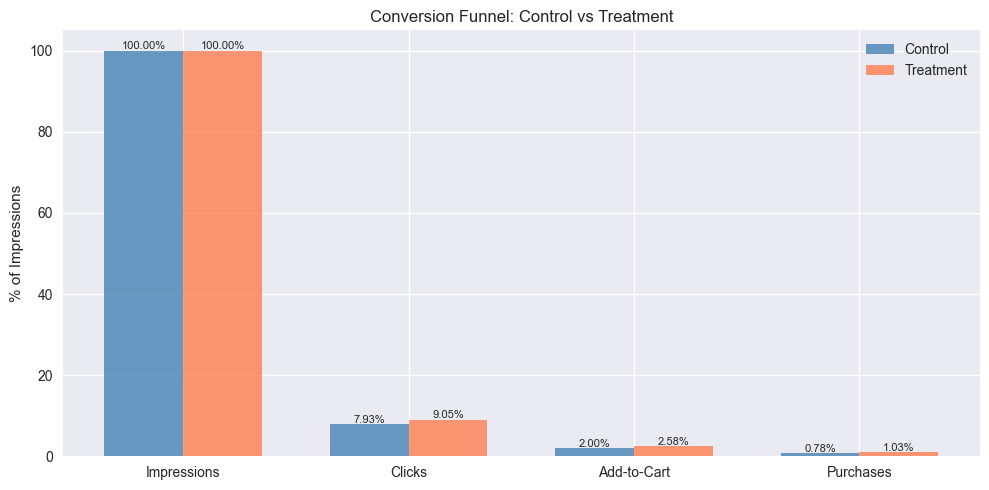

In [4]:
# Funnel visualisation
funnel_stages = ['Impressions', 'Clicks', 'Add-to-Cart', 'Purchases']
control_vals = []
treatment_vals = []

for grp, vals_list in [('control', control_vals), ('treatment', treatment_vals)]:
    grp_data = df[df['group'] == grp]
    vals_list.extend([
        grp_data['impressions'].sum(),
        grp_data['clicks'].sum(),
        grp_data['add_to_cart'].sum(),
        grp_data['purchases'].sum(),
    ])

# Normalise to percentages relative to impressions
ctrl_pct = [100 * v / control_vals[0] for v in control_vals]
treat_pct = [100 * v / treatment_vals[0] for v in treatment_vals]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(funnel_stages))
width = 0.35
ax.bar(x - width/2, ctrl_pct, width, label='Control', color='steelblue', alpha=0.8)
ax.bar(x + width/2, treat_pct, width, label='Treatment', color='coral', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(funnel_stages)
ax.set_ylabel('% of Impressions')
ax.set_title('Conversion Funnel: Control vs Treatment')
ax.legend()
for i in range(len(funnel_stages)):
    ax.text(i - width/2, ctrl_pct[i] + 0.3, f'{ctrl_pct[i]:.2f}%', ha='center', fontsize=8)
    ax.text(i + width/2, treat_pct[i] + 0.3, f'{treat_pct[i]:.2f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## 3. Engagement Metrics

Engagement metrics capture how deeply users interact with the platform:

| Metric | What it captures |
|--------|------------------|
| Session duration | Time spent on the platform per visit |
| Scroll depth | How far users scroll through the feed |
| Items viewed per session | Breadth of exploration |

> **⚠️ Common Pitfall:** Longer session duration is not always better. It could indicate users are struggling to find what they want. Always pair duration with conversion metrics.

Engagement Metrics by Group:
          session_duration_s                scroll_depth        impressions
                        mean median     std         mean median        mean
group                                                                      
control               122.82  84.88  121.53         0.40   0.39        9.97
treatment             139.76  95.84  142.21         0.46   0.45       11.51


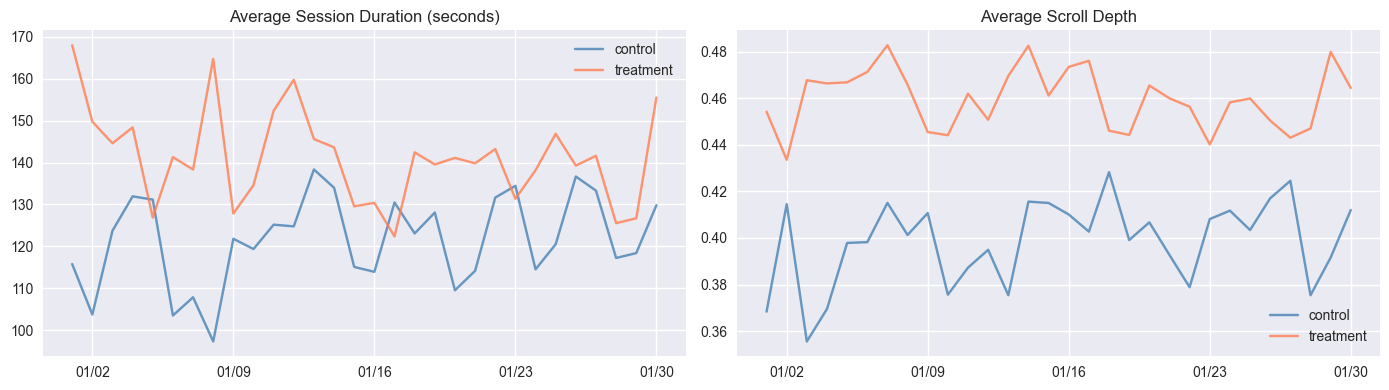

In [5]:
# Engagement metrics by group
engagement = df.groupby('group').agg({
    'session_duration_s': ['mean', 'median', 'std'],
    'scroll_depth': ['mean', 'median'],
    'impressions': 'mean',
}).round(2)

print("Engagement Metrics by Group:")
print(engagement)

# Daily engagement trends
daily_eng = df.groupby(['date', 'group']).agg({
    'session_duration_s': 'mean',
    'scroll_depth': 'mean'
}).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for grp, color in [('control', 'steelblue'), ('treatment', 'coral')]:
    mask = daily_eng['group'] == grp
    axes[0].plot(daily_eng.loc[mask, 'date'], daily_eng.loc[mask, 'session_duration_s'],
                 label=grp, color=color, alpha=0.8)
    axes[1].plot(daily_eng.loc[mask, 'date'], daily_eng.loc[mask, 'scroll_depth'],
                 label=grp, color=color, alpha=0.8)

axes[0].set_title('Average Session Duration (seconds)')
axes[0].legend()
axes[0].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

axes[1].set_title('Average Scroll Depth')
axes[1].legend()
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

plt.tight_layout()
plt.show()

## 4. Retention Metrics

Retention measures whether users come back after their first visit:

$$\text{D-N Retention} = \frac{\text{Users active on day N after signup}}{\text{Users who signed up on that cohort day}}$$

Standard retention windows: D1, D7, D30.

Reference: Chen et al., "Retention as a North Star: Measurement and Prediction at Scale" (KDD 2019, Netflix).

Retention Rates:
     control  treatment
D1    0.2810     0.3019
D3    0.2910     0.2820
D7    0.2508     0.2840
D14   0.2679     0.2542


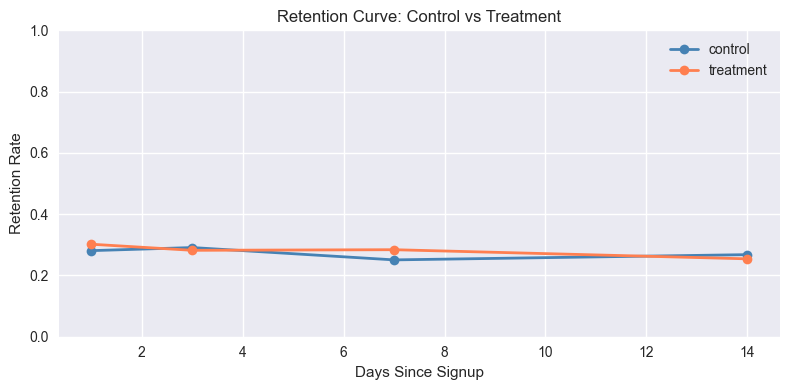

In [6]:
def compute_retention(df, user_signup_day, num_users, group, retention_days=[1, 3, 7, 14, 30]):
    """Compute D-N retention for each group."""
    results = {}
    for grp in ['control', 'treatment']:
        grp_users = [u for u in range(num_users) if group[u] == grp]
        grp_df = df[df['group'] == grp]
        
        retention = {}
        for d in retention_days:
            eligible = [u for u in grp_users if user_signup_day[u] + d < NUM_DAYS]
            if not eligible:
                retention[f'D{d}'] = 0.0
                continue
            retained = 0
            for u in eligible:
                target_day = user_signup_day[u] + d
                if len(grp_df[(grp_df['user_id'] == u) & (grp_df['day'] == target_day)]) > 0:
                    retained += 1
            retention[f'D{d}'] = retained / len(eligible)
        results[grp] = retention
    return results

retention = compute_retention(df, user_signup_day, NUM_USERS, group, [1, 3, 7, 14])
print("Retention Rates:")
retention_df = pd.DataFrame(retention).round(4)
print(retention_df)

# Plot retention curve
fig, ax = plt.subplots(figsize=(8, 4))
days_labels = [1, 3, 7, 14]
for grp, color in [('control', 'steelblue'), ('treatment', 'coral')]:
    vals = [retention[grp][f'D{d}'] for d in days_labels]
    ax.plot(days_labels, vals, 'o-', color=color, label=grp, linewidth=2)
ax.set_xlabel('Days Since Signup')
ax.set_ylabel('Retention Rate')
ax.set_title('Retention Curve: Control vs Treatment')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 5. Long-term Metrics and LTV

User Lifetime Value (LTV) estimates the total revenue a user generates over their lifetime:

$$\text{LTV} = \sum_{t=0}^{T} \gamma^t \cdot \text{Revenue}_t$$

where $\gamma$ is a discount factor (e.g., 0.95) accounting for the time value of money and uncertainty.

> **🔑 Pro Tip:** In practice, LTV is estimated from the first N days of behaviour. Many companies use a 90-day LTV prediction model trained on features from the first 7 days of user activity.

In [7]:
# Compute per-user LTV with discount factor
gamma = 0.98  # daily discount

user_ltv = {}
for uid in range(NUM_USERS):
    user_data = df[df['user_id'] == uid].sort_values('day')
    if len(user_data) == 0:
        user_ltv[uid] = 0.0
        continue
    signup = user_signup_day[uid]
    discounted_rev = 0.0
    for _, row in user_data.iterrows():
        t = row['day'] - signup
        discounted_rev += (gamma ** t) * row['revenue']
    user_ltv[uid] = discounted_rev

ltv_df = pd.DataFrame([
    {'user_id': uid, 'ltv': user_ltv[uid], 'group': group[uid]}
    for uid in range(NUM_USERS)
])

print("LTV Summary by Group:")
print(ltv_df.groupby('group')['ltv'].describe().round(2))

LTV Summary by Group:
            count   mean    std  min  25%  50%    75%     max
group                                                        
control     993.0   9.66  23.16  0.0  0.0  0.0   7.87  299.09
treatment  1007.0  15.55  29.96  0.0  0.0  0.0  19.72  255.57


## 6. North Star Metrics and Trade-offs

| Product Type | Typical North Star | Why |
|---|---|---|
| E-commerce | GMV per user | Directly tied to revenue |
| Content/Media | Watch time / session duration | Engagement drives ad revenue |
| Social | DAU/MAU ratio | Reflects habitual usage |
| Marketplace | Transactions per active user | Balances buyer and seller value |

> **⚠️ Common Pitfall:** Optimising CTR can increase clickbait recommendations, hurting long-term user satisfaction and retention. Always monitor guardrail metrics alongside the North Star.

### Metric Trade-off Analysis

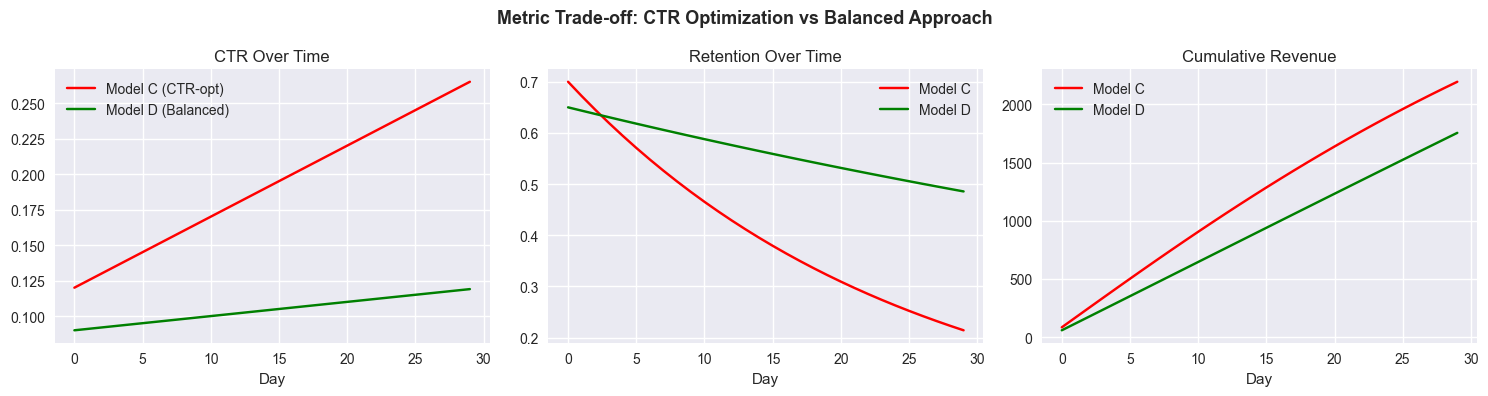

Day-30 cumulative revenue: Model C = $2194, Model D = $1755


In [8]:
# Simulate a scenario: Model C optimises CTR aggressively (clickbait)
# vs Model D which optimises for balanced engagement
np.random.seed(99)
n_sim_days = 30

# Model C: high CTR but declining retention
ctr_c = 0.12 + 0.005 * np.arange(n_sim_days)  # CTR increases
retention_c = 0.7 * (0.96 ** np.arange(n_sim_days))  # retention declines fast
revenue_c = ctr_c * retention_c * 1000  # proxy

# Model D: moderate CTR but stable retention
ctr_d = 0.09 + 0.001 * np.arange(n_sim_days)
retention_d = 0.65 * (0.99 ** np.arange(n_sim_days))  # retention declines slowly
revenue_d = ctr_d * retention_d * 1000

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ctr_c, label='Model C (CTR-opt)', color='red')
axes[0].plot(ctr_d, label='Model D (Balanced)', color='green')
axes[0].set_title('CTR Over Time')
axes[0].set_xlabel('Day')
axes[0].legend()

axes[1].plot(retention_c, label='Model C', color='red')
axes[1].plot(retention_d, label='Model D', color='green')
axes[1].set_title('Retention Over Time')
axes[1].set_xlabel('Day')
axes[1].legend()

axes[2].plot(np.cumsum(revenue_c), label='Model C', color='red')
axes[2].plot(np.cumsum(revenue_d), label='Model D', color='green')
axes[2].set_title('Cumulative Revenue')
axes[2].set_xlabel('Day')
axes[2].legend()

plt.suptitle('Metric Trade-off: CTR Optimization vs Balanced Approach', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Day-30 cumulative revenue: Model C = ${np.cumsum(revenue_c)[-1]:.0f}, Model D = ${np.cumsum(revenue_d)[-1]:.0f}")

## 7. Exercises

### Exercise 1: Build a Metric Dashboard

In [9]:
# 🏋️ Exercise 1: Build a Metric Dashboard
#
# TODO: Create a function `metric_dashboard(df, group_col)` that:
# 1. Computes daily CTR, CVR, GMV, avg session duration for each group
# 2. Plots a 2x2 grid of time series (one per metric)
# 3. Prints a summary table with % lift of treatment over control
#
# The function should work with any DataFrame following the schema of `df`.

def metric_dashboard(data, group_col='group'):
    # --- YOUR CODE HERE ---
    pass
    # --- END YOUR CODE ---

# Test: metric_dashboard(df)

### Exercise 2: Cohort Retention Analysis

In [10]:
# 🏋️ Exercise 2: Cohort Retention Analysis
#
# TODO: Implement a cohort retention table:
# 1. Group users by their signup week (week 1 = days 0-6, week 2 = days 7-13)
# 2. For each cohort, compute the retention rate at day 1, 3, 7 after signup
# 3. Create a heatmap of the retention table (cohort x retention day)
#
# Hint: Use plt.imshow() or plt.pcolormesh() for the heatmap

# --- YOUR CODE HERE ---

# --- END YOUR CODE ---

### Exercise 3: North Star Metric Selection

In [11]:
# 🏋️ Exercise 3: North Star Metric Selection
#
# TODO: You are given a streaming platform dataset (simulated below).
# Compute the correlation between these candidate North Star metrics
# and 30-day retention:
#   - Total watch time (minutes)
#   - Number of unique titles watched
#   - Number of sessions
#   - CTR on recommendations
#
# Which metric best predicts D30 retention? Why?

n_stream_users = 500
rng2 = np.random.RandomState(123)

streaming_data = pd.DataFrame({
    'user_id': range(n_stream_users),
    'watch_time_min': rng2.exponential(120, n_stream_users),
    'unique_titles': rng2.poisson(8, n_stream_users),
    'num_sessions': rng2.poisson(5, n_stream_users),
    'ctr': rng2.beta(2, 20, n_stream_users),
})

# D30 retention correlates most with unique_titles and watch_time
logit = (0.01 * streaming_data['watch_time_min'] +
         0.15 * streaming_data['unique_titles'] +
         0.05 * streaming_data['num_sessions'] +
         0.5 * streaming_data['ctr'] +
         rng2.normal(0, 0.5, n_stream_users))
streaming_data['d30_retained'] = (1 / (1 + np.exp(-logit + 2)) > 0.5).astype(int)

# --- YOUR CODE HERE ---
# Compute correlations and identify the best North Star metric

# --- END YOUR CODE ---

### Exercise 4: Guardrail Metrics

In [12]:
# 🏋️ Exercise 4: Guardrail Metrics
#
# TODO: Implement a guardrail check function that takes experiment results
# and raises warnings if:
#   1. Session duration decreases by more than 5%
#   2. D7 retention drops by more than 2 percentage points
#   3. The variance of per-user revenue increases by more than 20%
#      (indicates the model is making some users much worse off)

def check_guardrails(control_metrics, treatment_metrics):
    """Check guardrail metrics and return list of warnings."""
    warnings = []
    # --- YOUR CODE HERE ---
    
    # --- END YOUR CODE ---
    return warnings

# Test with example data
# control_m = {'session_duration': 120, 'd7_retention': 0.45, 'revenue_var': 100}
# treatment_m = {'session_duration': 110, 'd7_retention': 0.42, 'revenue_var': 130}
# print(check_guardrails(control_m, treatment_m))

## Summary

In this notebook we covered:

- **Conversion funnel metrics** (CTR, CVR, GMV) — the bread and butter of online evaluation
- **Engagement metrics** (session duration, scroll depth) — proxies for user satisfaction
- **Retention metrics** (D1/D7/D30) — critical for long-term health
- **LTV** — the ultimate long-term business metric
- **North Star metrics** — choosing the right primary metric for your product
- **Metric trade-offs** — optimising short-term metrics can harm long-term outcomes

**Key takeaway:** Online metrics form a hierarchy from short-term (CTR) to long-term (LTV). A healthy recommendation system should show improvements across multiple time horizons, with guardrail metrics preventing degradation in any critical dimension.